# EMC Feature Distribution Analysis (Full Segments)

This notebook analyzes the distributions of EMC features extracted over the full segments, using the same approach as the 10s epochs analysis. It loads feature files, computes statistical tests, and visualizes the distributions for healthy and epileptic classes.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import pickle as pkl
from scipy.stats import mannwhitneyu
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler 
plt.style.use('ggplot')
import itertools as it

# extend the print line width
np.set_printoptions(linewidth=200)
pd.options.display.max_columns = None
pd.options.display.max_rows = None

#suppress runtimewarnings
import warnings 
warnings.filterwarnings("ignore", category=RuntimeWarning)

# EMC feature path and description
feature_path = '/space/gzanardini/emc_whole/split/'
feature_list = [file for file in os.listdir(feature_path) if file.endswith('.npy')]
description = pd.read_csv(os.path.join(feature_path, 'description.csv'))
labels = description['epilepsy'].values

# Mann-Whitney U test function
def mann_whitney_u_test(x, y):
    stat, p = mannwhitneyu(x, y, alternative='two-sided')
    return p

def handle_complex_numbers(features):
    if isinstance(features, pd.DataFrame):
        for column in features.columns:
            if np.iscomplexobj(features[column]):
                features[column] = features[column].apply(np.abs)
            features[column].replace([np.inf, -np.inf], np.nan, inplace=True)
    elif isinstance(features, np.ndarray):
        if np.iscomplexobj(features):
            features = np.abs(features)
        features[~np.isfinite(features)] = np.nan
    return features

# Sort the feature list
feature_list.sort()

feature_names = ['cc', 'cwt', 'dwt', 'gcc', 'gplv', 'plv', 'mst', 'sst', 'spectral', 'utm']
combiners=['mean', 'median', 'std', 'skew','kurt']
montages = ['CAR', 'BipolarDB','Cz','Laplacian']
segment_lengths=[1,2,5,10, 20, 60]

feature_dict = {}
for feature in feature_names:
    feature_dict[feature] = [f for f in feature_list if f.startswith(feature)]

In [2]:
lowest_pval_df = pd.DataFrame(columns=["Montage", "SegLength", 'Combiner', 'Feature Index', "LowestPValue"], index=feature_names)

significant_features_df = pd.DataFrame(columns=["FeatureName", "Montage", "SegLength", "Combiner", "FeaturesIndexs", "PValues" ])
# Create a DataFrame to store the lowest p-values and corresponding parameters for each feature

for feature in feature_names:
    lowest_pval_df.loc[feature, :] = [None, None, None, None, np.inf]
 
    for idx, (montage, segment_length, combiner) in enumerate(it.product(montages, segment_lengths, combiners)):
        print(feature, idx, montage, segment_length, combiner)
        feature_file = f"{feature}_{montage}_{segment_length}s_{combiner}.npy"
        features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
        features = handle_complex_numbers(features)

        ps=np.array([mann_whitney_u_test(features[labels==0][:, i], features[labels==1][:, i]) for i in range(features.shape[1])])
        #apply bonferroni correction
        ps = ps * features.shape[1]
        ps = np.clip(ps, 0, 1)     
        lowest_indices = np.where(ps < 0.05)[0]
        lowest_indices_sorted = lowest_indices[np.argsort(ps[lowest_indices])]
        lowest_10 = lowest_indices_sorted[:10]
 
        significant = pd.DataFrame({
            "FeatureName": feature,
            "Montage": montage,
            "SegLength": segment_length,
            "Combiner": combiner,
            "FeaturesIndexs": lowest_indices_sorted.tolist(),
            "PValues": ps[lowest_indices_sorted].tolist()
        })

        significant_features_df = pd.concat([significant_features_df, significant], ignore_index=True)

        # Update the lowest p-value DataFrame
        if len(lowest_indices) > 0 and min(ps[lowest_indices]) < lowest_pval_df.loc[feature, 'LowestPValue']:
            lowest_pval_df.loc[feature, 'Montage'] = montage
            lowest_pval_df.loc[feature, 'SegLength'] = segment_length
            lowest_pval_df.loc[feature, 'Combiner'] = combiner
            lowest_pval_df.loc[feature, 'Feature Index'] = lowest_indices_sorted[0]
            lowest_pval_df.loc[feature, 'LowestPValue'] = ps[lowest_indices_sorted[0]]


cc 0 CAR 1 mean
cc 1 CAR 1 median
cc 2 CAR 1 std
cc 3 CAR 1 skew
cc 4 CAR 1 kurt
cc 5 CAR 2 mean
cc 6 CAR 2 median
cc 7 CAR 2 std
cc 8 CAR 2 skew
cc 9 CAR 2 kurt
cc 10 CAR 5 mean
cc 11 CAR 5 median
cc 12 CAR 5 std
cc 13 CAR 5 skew
cc 14 CAR 5 kurt
cc 15 CAR 10 mean
cc 16 CAR 10 median
cc 17 CAR 10 std
cc 18 CAR 10 skew
cc 19 CAR 10 kurt
cc 20 CAR 20 mean
cc 21 CAR 20 median
cc 22 CAR 20 std
cc 23 CAR 20 skew
cc 24 CAR 20 kurt
cc 25 CAR 60 mean
cc 26 CAR 60 median
cc 27 CAR 60 std
cc 28 CAR 60 skew
cc 29 CAR 60 kurt
cc 30 BipolarDB 1 mean
cc 31 BipolarDB 1 median
cc 32 BipolarDB 1 std
cc 33 BipolarDB 1 skew
cc 34 BipolarDB 1 kurt
cc 35 BipolarDB 2 mean
cc 36 BipolarDB 2 median
cc 37 BipolarDB 2 std
cc 38 BipolarDB 2 skew
cc 39 BipolarDB 2 kurt
cc 40 BipolarDB 5 mean
cc 41 BipolarDB 5 median
cc 42 BipolarDB 5 std
cc 43 BipolarDB 5 skew
cc 44 BipolarDB 5 kurt
cc 45 BipolarDB 10 mean
cc 46 BipolarDB 10 median
cc 47 BipolarDB 10 std
cc 48 BipolarDB 10 skew
cc 49 BipolarDB 10 kurt
cc 50 Bipo

In [3]:
lowest_pval_df

,Montage,SegLength,Combiner,Feature Index,LowestPValue
cc,CAR,20,skew,59,0.019564
cwt,BipolarDB,20,skew,326,0.017496
dwt,Laplacian,2,kurt,6,0.002747
gcc,CAR,20,kurt,6,0.016973
gplv,None,None,None,None,inf
plv,BipolarDB,1,skew,335,0.022976
mst,BipolarDB,1,skew,54,0.045133
sst,CAR,5,std,1,0.046021
spectral,Laplacian,1,std,18,0.033367
utm,Cz,20,kurt,63,0.025308


In [4]:
significant_features_df

,FeatureName,Montage,SegLength,Combiner,FeaturesIndexs,PValues
0,cc,CAR,20,skew,59,0.019564
1,cc,BipolarDB,10,std,36,0.046697
2,cwt,BipolarDB,20,skew,326,0.017496
3,cwt,Cz,20,skew,222,0.017496
4,dwt,Laplacian,2,skew,6,0.006158
5,dwt,Laplacian,2,skew,7,0.029498
6,dwt,Laplacian,2,kurt,6,0.002747
7,gcc,CAR,20,kurt,6,0.016973
8,plv,BipolarDB,1,skew,335,0.022976
9,plv,Cz,60,std,330,0.027550


In [5]:
effect_sizes = []
for index, row in significant_features_df.iterrows():
    feature_name = row['FeatureName']
    montage = row['Montage']
    seg_length = row['SegLength']
    combiner = row['Combiner']
    feature_index = row['FeaturesIndexs']
    p_value = row['PValues']


    feature_file = f"{feature_name}_{montage}_{seg_length}s_{combiner}.npy"
    features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
    features = handle_complex_numbers(features)

    healthy_values = features[labels == 0][:, feature_index]
    epileptic_values = features[labels == 1][:, feature_index]

    n1 = len(healthy_values)
    n2 = len(epileptic_values)
    u_stat, _ = mannwhitneyu(healthy_values, epileptic_values)

    r_rb = 1 - (2 * u_stat) / (n1 * n2)
    effect_sizes.append({
        "FeatureName": feature_name,
        "Montage": montage,
        "SegLength": seg_length,
        "Combiner": combiner,
        "FeatureIndex": feature_index,
        "PValue": p_value,
        "EffectSize": r_rb
    })

effect_sizes_df = pd.DataFrame(effect_sizes)
effect_sizes_df

,FeatureName,Montage,SegLength,Combiner,FeatureIndex,PValue,EffectSize
0,cc,CAR,20,skew,59,0.019564,0.417822
1,cc,BipolarDB,10,std,36,0.046697,0.391089
2,cwt,BipolarDB,20,skew,326,0.017496,0.446535
3,cwt,Cz,20,skew,222,0.017496,0.446535
4,dwt,Laplacian,2,skew,6,0.006158,0.471287
5,dwt,Laplacian,2,skew,7,0.029498,0.432673
6,dwt,Laplacian,2,kurt,6,0.002747,0.490099
7,gcc,CAR,20,kurt,6,0.016973,-0.361386
8,plv,BipolarDB,1,skew,335,0.022976,0.456436
9,plv,Cz,60,std,330,0.027550,-0.451980


cc
cc
cwt
cwt
dwt
dwt
dwt
gcc
plv
plv
mst
sst
spectral
spectral
utm
utm


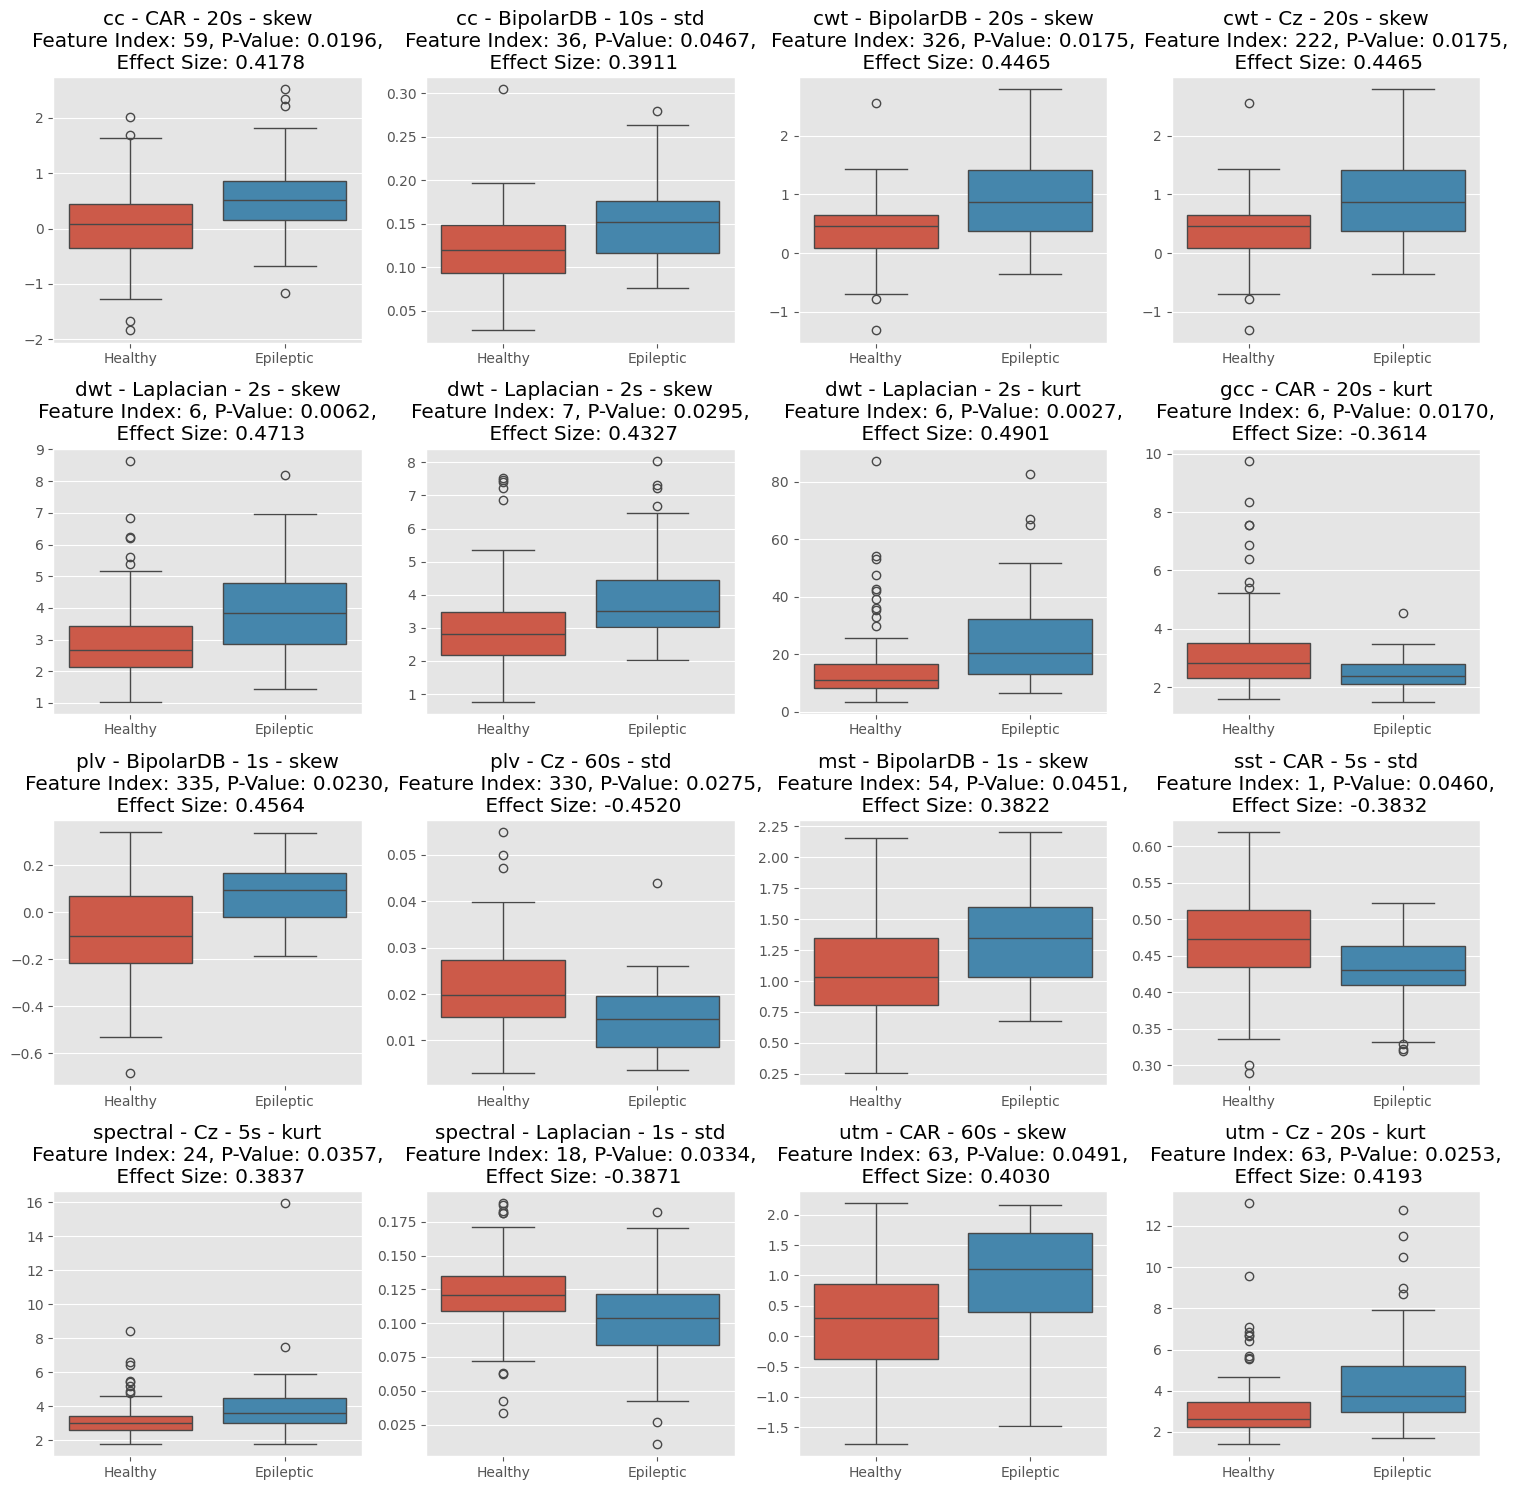

In [6]:
#print in a 4x4 grid the boxplots of the features with the lowest p-values, include effect size  and p value in the title
# one plot per each row of effect_sizes_df, separating epileptic and healthy values
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
for i, (index, row) in enumerate(effect_sizes_df.iterrows()):
    feature_name = row['FeatureName']
    montage = row['Montage']
    seg_length = row['SegLength']
    combiner = row['Combiner']
    feature_index = row['FeatureIndex']
    p_value = row['PValue']
    effect_size = row['EffectSize']

    feature_file = f"{feature_name}_{montage}_{seg_length}s_{combiner}.npy"
    features = np.load(os.path.join(feature_path, feature_file), allow_pickle=True)
    features = handle_complex_numbers(features)

    ax = axes[i // 4, i % 4]

    print(feature_name)
    
    healthy_values = features[labels == 0][:, feature_index]
    epileptic_values = features[labels == 1][:, feature_index]

    sns.boxplot(data=[healthy_values, epileptic_values], ax=ax)
    ax.set_title(f"{feature_name} - {montage} - {seg_length}s - {combiner}\n"
                 f"Feature Index: {feature_index}, P-Value: {p_value:.4f},\n Effect Size: {effect_size:.4f}")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Healthy', 'Epileptic'])
plt.tight_layout()

